# FS→DSA Final Analysis — Finland

This notebook guides through an analysis of Finland's MTP and the implications of policy-dependent potential output within the DSA. It can be run top-to-bottom without prior knowledge of the codebase. 

What the notebook will do:
- Load the FS and DSA models. For this excercise, only the supply block of the FS model is relevant: with no structural changes in taxation, the FS supply block is basically equivalent to the key trend equations in the PREM model.
- Enter MTP-informed baseline paths (SPB, potential growth & inflation)
    - Reasoning: We are asusming that the policies named in the MTP are consistent with the specified potential output and inflation paths. I.e.: The specified policy mix will lead to the specified macroeconomic conditions.
    - As GDP is endogenously calculated in the DSA based on PO and output gap, we do not use the (already endogenous) GDP path from the MTP as the baseline.
- Evaluate whether the SPB path from the MTP is still the binding SPB path given newly available data.
- Find the actual binding SPB path to form our baseline.
- Calibrate FS baseline to DSA.
- Run a policy scenario in FS and port it back to DSA.
- Compute the binding SPB path under different potential output assumptuons and compare baseline and scenario SPB target (fiscal space assessment)


## 1) Setup and imports

In [1]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Add the model directories to Python path
sys.path.append('model/fs')
sys.path.append('model/dsa/code/classes')

# Direct imports (no package structure)
from data_functions import load_and_process_data
from model_equations import build_model
from scenario_functions import initialize_model, run_scenario_analysis
from integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb
from StochasticDsaModelClass import StochasticDsaModel as DSA

# Analysis toggles
START, END = 2025, 2041

## 2) Import data
Load FS data and prepare the DSA model. 

In [3]:

FI = load_and_process_data(data_folder='data', sheet_name='Finland')
FS_model = build_model(include_fiscal=True, include_kg_lag=False)
data_FI = FS_model.insertModelVar(FI)
print('FI data shape:', FI.shape)

# set output gap mechanism in private investment = 0 as we dont assume this effect in PREM yet (all other variables affecting private investment dont change, so no need to adjust them)
data_FI.loc[:, 'LAMBDA_IQ_M_4'] = 0

dsa_fi = DSA(country='FIN', start_year=2024, end_year=2041, adjustment_period=7, adjustment_start_year=2025, fiscal_multiplier_type='ec')
dsa_fi.project()  # seed baseline arrays
df_fi = dsa_fi.df(all=True)

FI data shape: (84, 223)


## 3) Specify MTP paths (SPB, potential growth, inflation) and policy measures
The dictionaries below can be edited to specify different assumptions.
- SPB: level path (% of GDP)
- rg_pot: potential GDP growth (percent)
- pi: GDP deflator inflation (percent); available only up to 2029/2031 — we auto-align later years


In [4]:
years_full = list(range(dsa_fi.start_year, dsa_fi.end_year + 1))

# --- SPB level path (adjusted), constant after last value ---
# Provided path: -0.37, 0.44, 1.1, 1.42, 1.78, 2.06, 2.34, 2.62 (assume 2024-2031)
mtfp_spb_points = {
    2024: -0.37, 2025: 0.44, 2026: 1.10, 2027: 1.42, 2028: 1.78,
    2029: 2.06, 2030: 2.34, 2031: 2.62
}
mtfp_spb = pd.Series(mtfp_spb_points).reindex(years_full).ffill().bfill()

# --- Potential GDP growth anchors (adjusted), constant after last value ---
# Provided path: 1.1, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9 (assume 2024-2031)
mtfp_rg_pot_points = {
    2024: 1.1, 2025: 0.9, 2026: 0.9, 2027: 0.9, 2028: 0.9,
    2029: 0.9, 2030: 0.9, 2031: 0.9
}
mtfp_rg_pot = pd.Series(mtfp_rg_pot_points).reindex(years_full).ffill().bfill()

# --- Inflation (adjusted), constant after last value ---
# Provided path: 3.9, 1.7, 2.1, 2.2, 2.2, 2.3, 2.3, 2.4, 2.4, 2.5, 2.6, 2.5, 2.5, 2.5, 2.4, 2.4, 2.4, 2.4, 2.3
# Assume 2024-2042 (19 years)
mtfp_pi_points = {
    2024: 3.9, 2025: 1.7, 2026: 2.1, 2027: 2.2, 2028: 2.2, 2029: 2.3, 2030: 2.3,
    2031: 2.4, 2032: 2.4, 2033: 2.5, 2034: 2.6, 2035: 2.5, 2036: 2.5, 2037: 2.5,
    2038: 2.4, 2039: 2.4, 2040: 2.4, 2041: 2.4, 2042: 2.3
}


In [5]:
# Apply your MTP inflation and potential growth assumptions
mtp_anchors = {
    'rg_pot': pd.Series(mtfp_rg_pot),  # Potential growth
    'pi': mtfp_pi_points,              # Inflation path
}

# Convert your SPB level path to steps directly
a0 = dsa_fi.adjustment_start  # This is 1 (2025)
a1 = dsa_fi.adjustment_end    # This is 7 (2031)
years = np.arange(dsa_fi.start_year, dsa_fi.end_year + 1)  # [2024, 2025, ..., 2045]

# Get your SPB levels aligned to model years
spb_full = mtfp_spb.reindex(years).to_numpy()

# Calculate steps for adjustment period only
spb_steps = np.zeros(dsa_fi.adjustment_period)  # Array of 7 zeros
for t in range(a0, a1 + 1):  # t goes from 1 to 7
    spb_steps[t - a0] = spb_full[t] - spb_full[t - 1]

print(f"SPB steps: {spb_steps}")
print(f"SPB levels: {spb_full[1:8]}")  # Show the levels for 2025-2031

SPB steps: [0.81 0.66 0.32 0.36 0.28 0.28 0.28]
SPB levels: [0.44 1.1  1.42 1.78 2.06 2.34 2.62]


## 4) Initialise baseline

Project the debt ratio with the planned policies, assuming that they will lead to the specified potential output, SPB, and inflation changes/levels specified in the plan.

In [6]:
dsa_fi.spb_bca[0] = -0.37
dsa_fi.spb[0] = -0.37
apply_mtp_anchors_to_dsa(dsa_fi, anchors=mtp_anchors, inplace=True)
dsa_fi.growth_driven_preclosure = False
dsa_fi.project(spb_steps=spb_steps)
df_fi = dsa_fi.df(all=True)


In [9]:
dsa_bl_opt = copy.deepcopy(dsa_fi)
dsa_bl_opt.find_spb_binding(print_results=False)
df_bl_opt = dsa_bl_opt.df(all=True)
print(f"SPB: {dsa_fi.spb_bca[7]:.2f}% vs Binding: {dsa_bl_opt.binding_spb_target:.2f}%")

SPB: 2.62% vs Binding: 2.37%


In [10]:
# Extract rg_pot and pi series from dsa_bl_opt
rg = pd.Series(dsa_bl_opt.rg, index=years, name='rg')
rg_pot = pd.Series(dsa_bl_opt.rg_pot, index=years, name='rg_pot')
pi = pd.Series(dsa_bl_opt.pi, index=years, name='pi')

bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}

In [11]:
baseline_FI = initialize_model(
    data=data_FI, 
    model_class=FS_model, 
    start=START, 
    end=END,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  # This should use your DSA model
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(dsa_bl_opt),  # Use the binding DSA model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

## 5) Scenario analysis
Estimate the impact of the policy measures in the FS model, then port the scenario potential into DSA for comparison.

In [12]:
# One-liner to get the growth rate
g = ((1 + 0.58/100) ** (1/6)) - 1
print(f"Required EPS_SR value: {g:.6f}")  # Output: 0.001156

Required EPS_SR value: 0.000964


In [14]:
#interpret: absolute means the value is added to the baseline value in that year, delta means only the change to the previous year is added
#persist: will changes persist after scenario timeframe (e.g., after adjustment period)?
#persist_mode: plateau means no further changes (e.g., if EPS_SR = 0.001, it will be 0 in the following years); 
#              copy_last means the last value copied forward (e.g., if EPS_SR = 0.001, EPS_SR will continue to be 0.001 in the following years)
measures = [
    # Public investment
    { 'var': 'S_IG_STAR', 'values': [0.07, 0.14, 0.21, 0.28, 0.35, 0.42], 'interpret': 'absolute', 'persist': False, 'persist_mode': 'copy_last' },
    # TFP impact: 0.30% increase in SR_TREND (0.0075 absolute increase) starting in 2029
    { 'var': 'EPS_SR', 'values': [0, 0, 0, 0, 0, 0.000964, 0.000964, 0.000964, 0.000964, 0.000964, 0.000964], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },

    # Private Investment
    { 'var': 'EPS_IQ_M', 'values': [0.08, 0.16, 0.24, 0.32, 0.4, 0.48], 'interpret': 'absolute', 'persist': False, 'persist_mode': 'copy_last' },
]

In [15]:
scenario_FI = run_scenario_analysis(
    baseline_result=baseline_FI, model_class=FS_model,
    scenario_shocks=measures, scenario_name='FI_policy', allow_fixed_shocks=True
)

,Period 1,Period 2,Period 3,Period 4,Period 5,Period 6,Period 7,Period 8,Period 9,Period 10,Period 11
S_IG_STAR,0.07,0.14,0.21,0.28,0.35,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
EPS_SR,0.00,0.00,0.00,0.00,0.00,0.000964,0.000964,0.000964,0.000964,0.000964,0.000964
EPS_IQ_M,0.08,0.16,0.24,0.32,0.40,0.480000,0.000000,0.000000,0.000000,0.000000,0.000000


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

Calculate a smoothed potential output growth path for better comparison to smoothed PO growth path in MTP.

In [17]:
# Calculate total growth from 2024 to 2041
start_value = baseline_FI.loc[2024, 'Y_STAR']
end_value = scenario_FI.loc[2041, 'Y_STAR']
total_growth_factor = end_value / start_value

# Calculate the constant annual growth rate from 2025 to 2041 (17 years)
years_span = 2041 - 2024  # 17 years
constant_growth_rate = (total_growth_factor ** (1/years_span)) - 1

# Create smoothed Y_STAR series with constant growth
scenario_FI['Y_STAR_smooth'] = scenario_FI['Y_STAR'].copy()
scenario_FI.loc[2024, 'Y_STAR_smooth'] = start_value

# Apply constant growth from 2025 onwards
for year in range(2025, 2042):
    scenario_FI.loc[year, 'Y_STAR_smooth'] = start_value * ((1 + constant_growth_rate) ** (year - 2024))

# Calculate the smoothed growth rates
scenario_FI['Y_STAR_growth_smooth'] = scenario_FI['Y_STAR_smooth'].pct_change() * 100

print(f"Total growth factor: {total_growth_factor:.4f}")
print(f"Constant annual growth rate: {constant_growth_rate*100:.2f}%")
print(f"Growth from 2024 to 2041: {(total_growth_factor-1)*100:.2f}%")

Total growth factor: 1.1782
Constant annual growth rate: 0.97%
Growth from 2024 to 2041: 17.82%


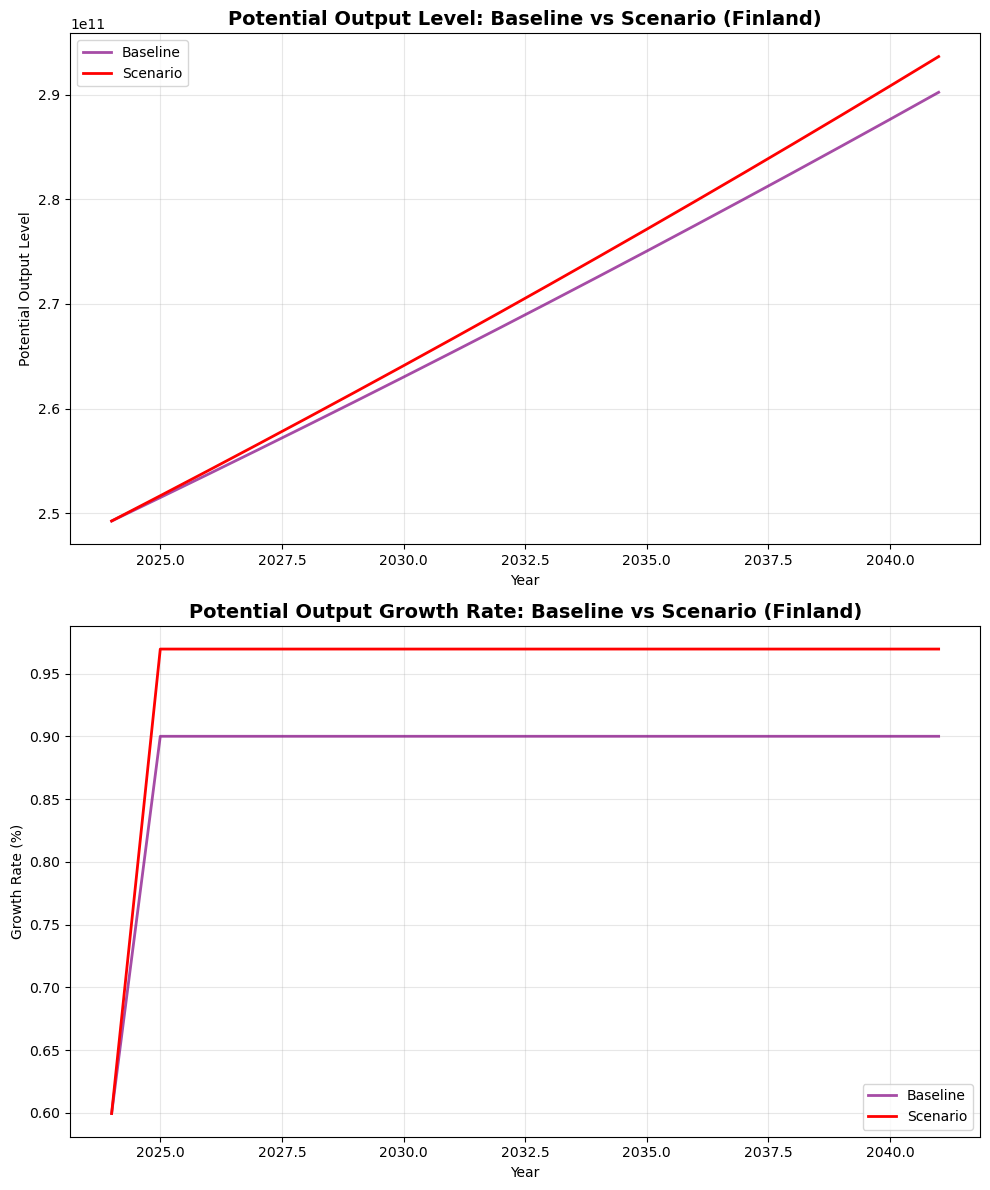

In [18]:
# Compare only baseline vs scenario (smoothed) for Finland
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Define years for x-axis (2024 to 2041)
years_plot = range(2024, 2042)

# First subplot: Baseline vs Scenario (smoothed) Y_STAR levels
ax1.set_title('Potential Output Level: Baseline vs Scenario (Finland)', fontsize=14, fontweight='bold')
ax1.plot(years_plot, baseline_FI.loc[years_plot, 'Y_STAR'], 
         color='purple', linestyle='-', linewidth=2, 
         label='Baseline', alpha=0.7)
ax1.plot(years_plot, scenario_FI.loc[years_plot, 'Y_STAR_smooth'], 
         color='red', linestyle='-', linewidth=2, 
         label='Scenario')
ax1.set_xlabel('Year')
ax1.set_ylabel('Potential Output Level')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Second subplot: Baseline vs Scenario (smoothed) growth rates
ax2.set_title('Potential Output Growth Rate: Baseline vs Scenario (Finland)', fontsize=14, fontweight='bold')
ax2.plot(years_plot, baseline_FI.loc[years_plot, 'G_Y_STAR'], 
         color='purple', linestyle='-', linewidth=2, 
         label='Baseline', alpha=0.7)
ax2.plot(years_plot, scenario_FI.loc[years_plot, 'Y_STAR_growth_smooth'], 
         color='red', linestyle='-', linewidth=2, 
         label='Scenario')
ax2.set_xlabel('Year')
ax2.set_ylabel('Growth Rate (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6) Optimal path & fiscal space
Compare binding SPB paths for baseline and scenario.

In [20]:
# Create DSA model
dsa_scenario = copy.deepcopy(dsa_fi)

# Apply only potential output from FS scenarios to DSA models (Finland)
apply_fs_potential_to_dsa(
    dsa_scenario, 
    fs_df=scenario_FI, 
    use_smoothed_growth=True,
    smooth_start_year=2024,  # Your start year
    smooth_end_year=2041     # Your end year
)

# Now run DSA projections for Finland
dsa_scenario.project(spb_steps=spb_steps)


In [22]:
#find optimal/binding SPB path
dsa_sce_opt = copy.deepcopy(dsa_scenario)
dsa_sce_opt.find_spb_binding(
        print_results=True
    )
df_sce_opt = dsa_sce_opt.df(all=True)
    
sce_opt_tgt = float(dsa_sce_opt.binding_spb_target)
sce_opt_steps = dsa_sce_opt.binding_parameter_dict['spb_steps'].copy()

print(f"Baseline Binding: {dsa_bl_opt.spb_bca[7]:.4f}% vs Scenario Binding: {dsa_sce_opt.binding_spb_target:.4f}%")


                  Model Params                              SPB Targets       
================================================     =========================
country                                      FIN     main_adjustment     0.937
adjustment period                              7     lower_spb           1.109
adjustment start                            2025     financial_stress    1.095
shock frequency                        quarterly     adverse_r_g         1.450
stochastic period                      2032-2037     deficit_reduction  -0.317
estimation                                normal     stochastic          1.407
bond level data                            False     edp                 1.442
safeguards         EDP, debt, deficit_resilience     debt_safeguard      2.252
                                                     binding             2.252
================================================     =========================

                                Binding Params     

In [26]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario

years = range(2024, 2042)  # 2025-2041 for

# Helper function to get EUR values
def get_eur_values_at(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values
def get_pct_values_at(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary including debt ratio and potential output growth
results = {
    'Year': years_at,
    'SPB_Baseline_%': [get_pct_values_at(dsa_bl_opt, y, 'spb_bca') for y in years_at],
    'SPB_Scenario_%': [get_pct_values_at(dsa_sce_opt, y, 'spb_bca') for y in years_at],
    'SPB_Baseline_EUR': [get_eur_values_at(dsa_bl_opt, y, 'spb_bca') for y in years_at],
    'SPB_Scenario_EUR': [get_eur_values_at(dsa_sce_opt, y, 'spb_bca') for y in years_at],
    'Debt_Baseline_%': [get_pct_values_at(dsa_bl_opt, y, 'd') for y in years_at],
    'Debt_Scenario_%': [get_pct_values_at(dsa_sce_opt, y, 'd') for y in years_at],
    'PotOut_Growth_Baseline_%': [get_pct_values_at(dsa_bl_opt, y, 'rg_pot') for y in years_at],
    'PotOut_Growth_Scenario_%': [get_pct_values_at(dsa_sce_opt, y, 'rg_pot') for y in years_at],
}

# Create DataFrame
comparison_df = pd.DataFrame(results)

# Calculate differences
comparison_df['SPB_Diff_%'] = comparison_df['SPB_Scenario_%'] - comparison_df['SPB_Baseline_%']
comparison_df['SPB_Diff_EUR'] = comparison_df['SPB_Scenario_EUR'] - comparison_df['SPB_Baseline_EUR']
comparison_df['Debt_Diff_%'] = comparison_df['Debt_Scenario_%'] - comparison_df['Debt_Baseline_%']
comparison_df['PotOut_Growth_Diff_%'] = comparison_df['PotOut_Growth_Scenario_%'] - comparison_df['PotOut_Growth_Baseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison:")
# Format EUR columns to show in billions (no scientific notation)
eur_cols = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display = comparison_df.copy()
for col in eur_cols:
    comparison_df_display[col] = comparison_df_display[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display.round(2))

SPB, Debt Ratio, and Potential Output Growth Comparison:


,Year,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Debt_Baseline_%,Debt_Scenario_%,PotOut_Growth_Baseline_%,PotOut_Growth_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-0.37,-0.37,"-1,021,836,400","-1,021,836,400",82.09,82.09,1.1,0.97,0.00,0,0.00,-0.13
1,2025,0.13,0.13,"368,216,831","368,470,492",84.50,84.44,0.9,0.97,0.00,"253,660",-0.06,0.07
2,2026,0.50,0.48,"1,480,872,839","1,424,198,870",85.60,85.48,0.9,0.97,-0.02,"-56,673,969",-0.11,0.07
3,2027,0.88,0.84,"2,672,621,264","2,556,592,086",85.96,85.80,0.9,0.97,-0.04,"-116,029,178",-0.15,0.07
4,2028,1.25,1.19,"3,942,206,331","3,764,532,912",85.97,85.79,0.9,0.97,-0.06,"-177,673,420",-0.17,0.07
5,2029,1.62,1.54,"5,295,689,716","5,053,916,576",85.16,84.99,0.9,0.97,-0.08,"-241,773,139",-0.17,0.07
6,2030,2.00,1.90,"6,732,839,705","6,424,648,075",84.13,83.98,0.9,0.97,-0.10,"-308,191,631",-0.15,0.07
7,2031,2.37,2.25,"8,264,930,079","7,887,633,801",83.10,82.98,0.9,0.97,-0.12,"-377,296,278",-0.11,0.07
8,2032,2.37,2.25,"8,568,923,266","8,182,243,712",81.77,81.72,0.9,0.97,-0.12,"-386,679,553",-0.05,0.07
9,2033,2.37,2.25,"8,892,668,382","8,496,053,966",80.13,80.15,0.9,0.97,-0.12,"-396,614,416",0.02,0.07


In [ ]:
# Save the comparison dataframe for Finland
#comparison_df_fi.to_excel('Finland_Results_v2.xlsx', index=False)
#print("DataFrame saved as 'Finland_Results_v2.xlsx'")

DataFrame saved as 'Finland_Results_v2.xlsx'
